# Подготовка данных и инструментов

## Загрузка и обработка данных

In [188]:
from pathlib import Path
import sys, os

REPO_DIR = 'Multiclass_prediction_of_obesity_risk'
REPO_URL = 'https://github.com/AlexTilta/Multiclass_prediction_of_obesity_risk.git'

if not os.path.isdir(REPO_DIR):
    print("Репозиторий не найден. Клонирование и установка зависимостей...")
    !git clone {REPO_URL}

    !pip -q install -r {REPO_DIR}/requirements.txt
else:
    print(f"Репозиторий '{REPO_DIR}' уже склонирован.")

%cd {REPO_DIR}

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


from src.utils import load_csv

# 3.2 Загрузка данных
df_original = load_csv('prepared_data.csv', 'data')
df_original.head()

Репозиторий не найден. Клонирование и установка зависимостей...
Cloning into 'Multiclass_prediction_of_obesity_risk'...
remote: Enumerating objects: 447, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 447 (delta 92), reused 143 (delta 48), pack-reused 237 (from 1)
Receiving objects: 100% (447/447), 20.87 MiB | 20.62 MiB/s, done.
Resolving deltas: 100% (178/178), done.
/content/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0000,1.6200,64.0000,yes,no,Sometimes,3,Sometimes,no,1-2,no,0,3-5,no,Public_Transportation,Normal_Weight,24.3865
1,Female,21.0000,1.5200,56.0000,yes,no,Always,3,Sometimes,yes,>2,yes,4-5,0-2,Sometimes,Public_Transportation,Normal_Weight,24.2382
2,Male,23.0000,1.8000,77.0000,yes,no,Sometimes,3,Sometimes,no,1-2,no,2-4,3-5,Frequently,Public_Transportation,Normal_Weight,23.7654
3,Male,27.0000,1.8000,87.0000,no,no,Always,3,Sometimes,no,1-2,no,2-4,0-2,Frequently,Walking,Overweight,26.8519
4,Male,22.0000,1.7800,89.8000,no,no,Sometimes,1-2,Sometimes,no,1-2,no,0,0-2,Sometimes,Public_Transportation,Overweight,28.3424


 ## Установка библиотек

In [189]:
!pip show catboost || pip install catboost
!pip show phik || pip install phik

Name: catboost
Version: 1.2.8
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 
Name: phik
Version: 0.12.5
Summary: Phi_K correlation analyzer library
Home-page: 
Author: 
Author-email: "KPMG N.V. The Netherlands" <kave@kpmg.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, matplotlib, numpy, pandas, scipy
Required-by: 


## Библиотеки

In [190]:
# Общие библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, PolynomialFeatures
)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
# Библиотеки для отчетов
import json
import time
from IPython.display import display

# Утилиты
import joblib
import warnings
warnings.filterwarnings('ignore')
from phik import phik_matrix


# Библиотеки моделей или для конкретных моделей
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier
)
from catboost import CatBoostClassifier, Pool, cv

# Настройка датасета

## Константы (для отчетов и редактирования наименований признаков)

In [191]:
# # Настройка целевых переменных
# TARGET_COLUMN = 'NObeyesdad'


# # Заметка: здесь есть переключатель между с BMI
# # и без BMI. Можно потом попробовать продублировать и попробовать с и без BMI
# WITH_BMI = ['Height', 'Weight']
# WITHOUT_BMI = ['BMI']
# COLUMNS_TO_DROP = [TARGET_COLUMN] + WITHOUT_BMI

TARGET_COLUMN = 'NObeyesdad'

ANTHROPOMETRICS = ['Height', 'Weight', 'BMI']

COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY = [TARGET_COLUMN, 'BMI']

COLUMNS_TO_DROP_BMI_ONLY = [TARGET_COLUMN, 'Height', 'Weight']

COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED = [TARGET_COLUMN] + ANTHROPOMETRICS



## Преобразование данных для большинство моделей

In [192]:
df_transformed = df_original.copy()

caec_calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_transformed['CAEC'] = df_transformed['CAEC'].replace(caec_calc_map)
df_transformed['CALC'] = df_transformed['CALC'].replace(caec_calc_map)

fcvc_map = {'no': 0, 'Sometimes': 1, 'Always': 2}
df_transformed['FCVC'] = df_transformed['FCVC'].replace(fcvc_map)

ncp_map = {'1-2': 1.5, '3': 3.0, '>3': 3.5}
df_transformed['NCP'] = df_transformed['NCP'].replace(ncp_map)

ch2o_map = {'<1': 0.5, 'Sometimes': 1.0, '1-2': 1.5, '>2': 3.0}
df_transformed['CH2O'] = df_transformed['CH2O'].replace(ch2o_map)

faf_tue_map = {'0': 0, 'no': 0, '0-2': 1, '1-2': 1, '2-4': 3,
               '3-5': 4, '4-5': 4, '>5': 5}
df_transformed['FAF'] = df_transformed['FAF'].replace(faf_tue_map)
df_transformed['TUE'] = df_transformed['TUE'].replace(faf_tue_map)

yes_no_map = {'yes': 1.0, 'no': 0.0}
df_transformed['family_history_with_overweight'] = df_transformed['family_history_with_overweight'].replace(yes_no_map)
df_transformed['FAVC'] = df_transformed['FAVC'].replace(yes_no_map)
df_transformed['SMOKE'] = df_transformed['SMOKE'].replace(yes_no_map)
df_transformed['SCC'] = df_transformed['SCC'].replace(yes_no_map)

gender_map = {'Male': 1.0, 'Female': 0.0}
df_transformed['Gender'] = df_transformed['Gender'].replace(gender_map)

mtrans_le = LabelEncoder()
df_transformed['MTRANS'] = mtrans_le.fit_transform(df_transformed['MTRANS']).astype(float)

df = df_transformed

INT_COLUMNS = ['FCVC', 'CAEC', 'FAF', 'TUE', 'CALC']
INT_COLUMNS_ADJUSTED = [col for col in INT_COLUMNS if col in df.columns]

for col in INT_COLUMNS_ADJUSTED:
    df[col] = df[col].astype('Int64')

EXCLUDE_COLUMNS = [TARGET_COLUMN] + INT_COLUMNS_ADJUSTED

COLUMNS_TO_FLOAT = [col for col in df.columns if col not in EXCLUDE_COLUMNS]

for col in COLUMNS_TO_FLOAT:
    try:
        df[col] = df[col].astype(float)
    except Exception as e:
        pass

print(df.dtypes)
df

Gender                            float64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight    float64
FAVC                              float64
FCVC                                Int64
NCP                               float64
CAEC                                Int64
SMOKE                             float64
CH2O                              float64
SCC                               float64
FAF                                 Int64
TUE                                 Int64
CALC                                Int64
MTRANS                            float64
NObeyesdad                         object
BMI                               float64
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0.0000,21.0000,1.6200,64.0000,1.0000,0.0000,1,3.0000,1,0.0000,1.5000,0.0000,0,4,0,3.0000,Normal_Weight,24.3865
1,0.0000,21.0000,1.5200,56.0000,1.0000,0.0000,2,3.0000,1,1.0000,3.0000,1.0000,4,1,1,3.0000,Normal_Weight,24.2382
2,1.0000,23.0000,1.8000,77.0000,1.0000,0.0000,1,3.0000,1,0.0000,1.5000,0.0000,3,4,2,3.0000,Normal_Weight,23.7654
3,1.0000,27.0000,1.8000,87.0000,0.0000,0.0000,2,3.0000,1,0.0000,1.5000,0.0000,3,1,2,4.0000,Overweight,26.8519
4,1.0000,22.0000,1.7800,89.8000,0.0000,0.0000,1,1.5000,1,0.0000,1.5000,0.0000,0,1,1,3.0000,Overweight,28.3424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.0000,20.9768,1.7107,131.4085,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,3,4,1,3.0000,Obesity,44.9015
2083,0.0000,21.9829,1.7486,133.7429,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,1,4,1,3.0000,Obesity,43.7419
2084,0.0000,22.5240,1.7522,133.6894,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,1,4,1,3.0000,Obesity,43.5438
2085,0.0000,24.3619,1.7394,133.3466,1.0000,1.0000,2,3.0000,1,0.0000,3.0000,0.0000,1,4,1,3.0000,Obesity,44.0715


# Общие объявления и функции для моделей

## Переменные для отчета

In [193]:
# Константы для названий моделей
MODEL_NAMES = {
    "log_reg": "Логистическая регрессия",
    "svm": "Модель SVM",
    "tree": "Деревья",
    "rf": "Рандом Форест",
    "stacking": "Стеггинг",
    "cat_boost": "CatBoost"
}

# Константы для названий метрик
METRIC_COLUMNS = {
    # Метрики качества
    "F1": "F1-Score (Weighted Avg)",
    "RECALL": "Recall (Weighted Avg)",
    "PRECISION" : "Precision (Weighted Avg)",
    "ACCURACY": "Accuracy",
    # Метрика скорости
    "TIME": "Время CV (сек)"
}

# Сохранение результатов
result_hw = {}
result_bmi = {}
result_no_anthro = {}

## Объявления x, y, а также тренировочных и тестовых переменных

### Без BMI

In [194]:
# --- Для большинства моделей (df) ---
X_HW = df.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y = df[TARGET_COLUMN]
X_HW_train, X_HW_test, Y_HW_train, Y_HW_test = train_test_split(X_HW, Y, random_state=42, stratify=Y)

X_HW_cat = df_original.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_HW_cat_train, X_HW_cat_test, Y_HW_cat_train, Y_HW_cat_test = train_test_split(X_HW_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### C BMI

In [195]:

# --- Для большинства моделей (df) ---
X_BMI = df.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y = df[TARGET_COLUMN]
X_BMI_train, X_BMI_test, Y_BMI_train, Y_BMI_test = train_test_split(X_BMI, Y, random_state=42, stratify=Y)


# --- Для CatBoost (df_original) ---
X_BMI_cat = df_original.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_BMI_cat_train, X_BMI_cat_test, Y_BMI_cat_train, Y_BMI_cat_test = train_test_split(X_BMI_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### Без BMI, без Роста и вес

In [196]:
# --- Для большинства моделей (df) ---
X_NO_ANTHRO = df.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y = df[TARGET_COLUMN]
X_NO_ANTHRO_train, X_NO_ANTHRO_test, Y_NO_ANTHRO_train, Y_NO_ANTHRO_test = train_test_split(X_NO_ANTHRO, Y, random_state=42, stratify=Y)

X_NO_ANTHRO_cat = df_original.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y_cat = df_original[TARGET_COLUMN]
X_NO_ANTHRO_cat_train, X_NO_ANTHRO_cat_test, Y_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_test = train_test_split(X_NO_ANTHRO_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

## Функции для запуска моделей и вывода их результата

Также в этих функциях происходит получение отчетности данных точности и времени

make_model - для большинства моделей

In [197]:
def make_model(pipeline, x, y, model_name, results_dict):
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    start_time = time.time()

    y_pred_cv_full = cross_val_predict(estimator=pipeline,
                                       X=x,
                                       y=y,
                                       cv=stratified_kfold,
                                       n_jobs=-1)

    end_time = time.time()
    cv_time_seconds = end_time - start_time

    class_names = [str(c) for c in sorted(y.unique())]

    report = classification_report(y, y_pred_cv_full, target_names=class_names, output_dict=True)

    weighted_f1_score = report['weighted avg']['f1-score']
    weighted_recall = report['weighted avg']['recall']
    weighted_precision = report['weighted avg']['precision']
    overall_accuracy = report['accuracy']

    results_dict[model_name] = {
          METRIC_COLUMNS["F1"]: weighted_f1_score,
          METRIC_COLUMNS["RECALL"]: weighted_recall,
          METRIC_COLUMNS["PRECISION"]: weighted_precision,
          METRIC_COLUMNS["ACCURACY"]: overall_accuracy,
          METRIC_COLUMNS["TIME"]: cv_time_seconds
      }

    print("Classification Report - Full Model CV:")
    print(classification_report(y, y_pred_cv_full, target_names=class_names))

    cm = confusion_matrix(y, y_pred_cv_full)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Full Model CV')
    plt.show()

make_catboost_model - только для catboost

In [221]:
def make_catboost_model(model, x, y, cat_features ,model_name, results_dict):
  start_time = time.time()
  cv_data = cv(
      Pool(x, y, cat_features=cat_features),
      model.get_params(),
      fold_count=5,
      seed=42
  )

  end_time = time.time()
  cv_time_seconds = end_time - start_time

  results_dict['catBoost'] = {
    METRIC_COLUMNS["F1"]: 0,
    METRIC_COLUMNS["RECALL"]: 0,
    METRIC_COLUMNS["PRECISION"]: 0,
    METRIC_COLUMNS["ACCURACY"]: cv_data['test-Accuracy-mean'].max(),
    METRIC_COLUMNS["TIME"]: cv_time_seconds
  }

# Логистическая регрессия

In [199]:
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.98      0.94       200
      Normal_Weight       0.90      0.71      0.79       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.90      0.96      0.93       424

           accuracy                           0.94      1565
          macro avg       0.92      0.91      0.91      1565
       weighted avg       0.94      0.94      0.94      1565



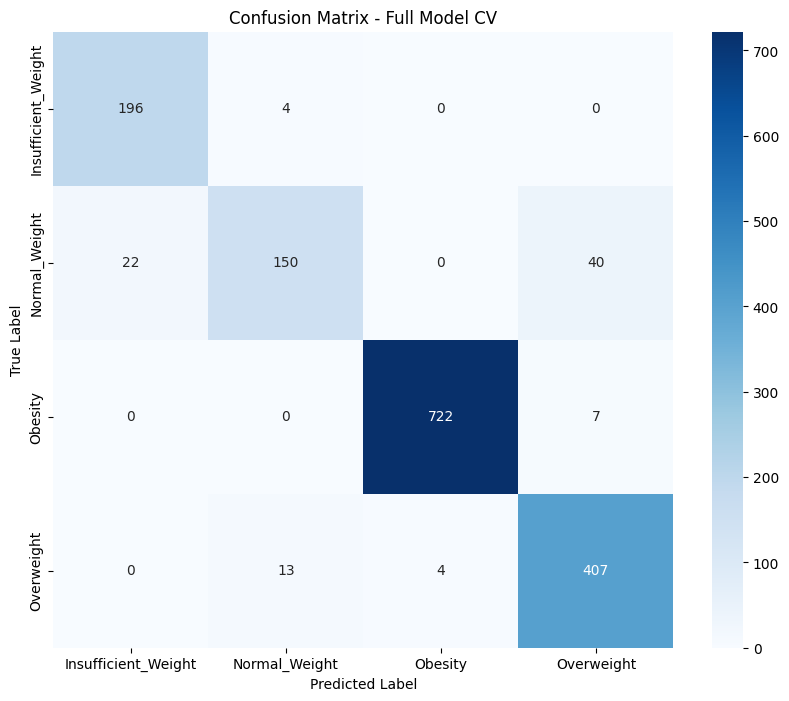

In [200]:
make_model(logreg_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["log_reg"], result_hw)

## C BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.98      0.94       200
      Normal_Weight       0.94      0.76      0.84       212
            Obesity       1.00      0.99      0.99       729
         Overweight       0.92      0.98      0.95       424

           accuracy                           0.96      1565
          macro avg       0.94      0.93      0.93      1565
       weighted avg       0.96      0.96      0.96      1565



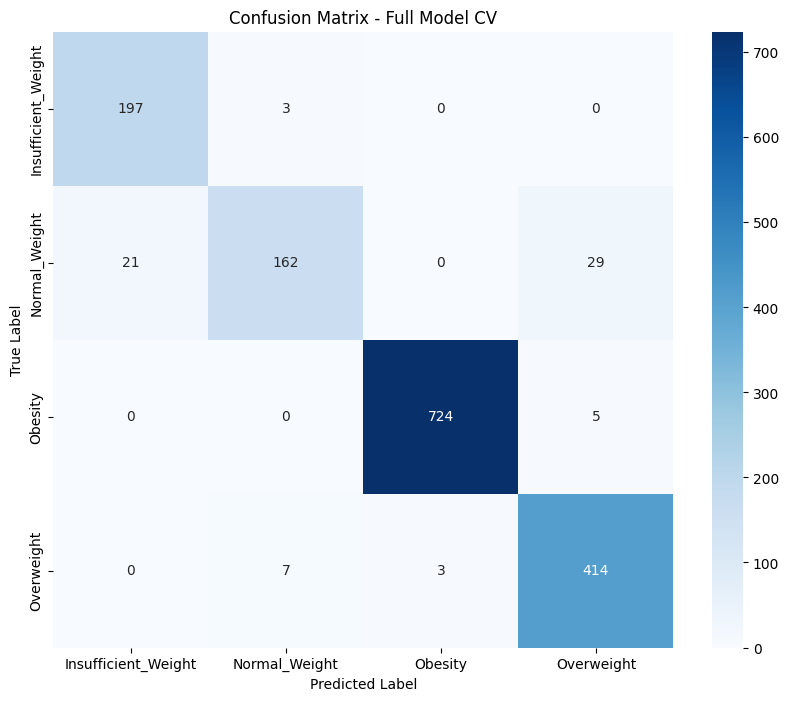

In [201]:
make_model(logreg_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["log_reg"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.53      0.49      0.51       200
      Normal_Weight       0.42      0.30      0.35       212
            Obesity       0.67      0.90      0.77       729
         Overweight       0.50      0.29      0.37       424

           accuracy                           0.60      1565
          macro avg       0.53      0.49      0.50      1565
       weighted avg       0.57      0.60      0.57      1565



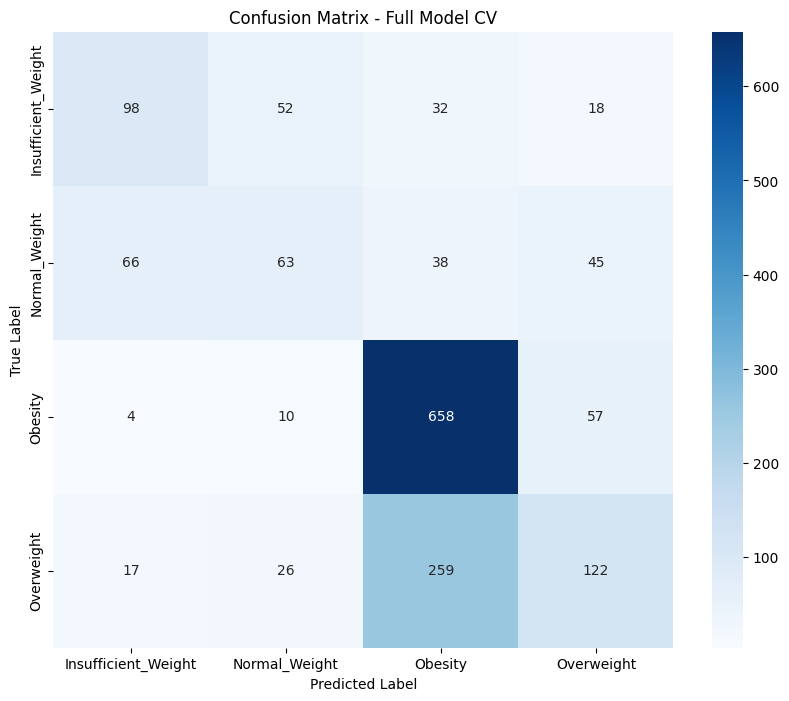

In [202]:
make_model(logreg_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["log_reg"], result_no_anthro)

# SVM

In [203]:
svm_pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', random_state=42)
    )

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.99      0.95       200
      Normal_Weight       0.98      0.84      0.91       212
            Obesity       1.00      0.99      0.99       729
         Overweight       0.95      0.99      0.97       424

           accuracy                           0.97      1565
          macro avg       0.96      0.95      0.96      1565
       weighted avg       0.97      0.97      0.97      1565



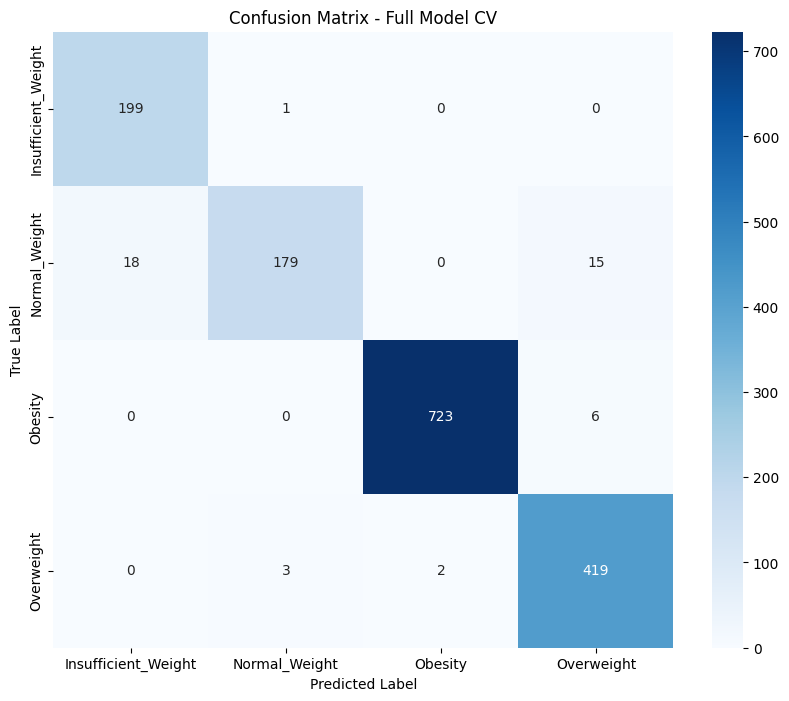

In [204]:
make_model(svm_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["svm"], result_hw)

## С BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.99      0.96       200
      Normal_Weight       0.97      0.87      0.92       212
            Obesity       1.00      0.99      1.00       729
         Overweight       0.97      0.98      0.97       424

           accuracy                           0.97      1565
          macro avg       0.96      0.96      0.96      1565
       weighted avg       0.97      0.97      0.97      1565



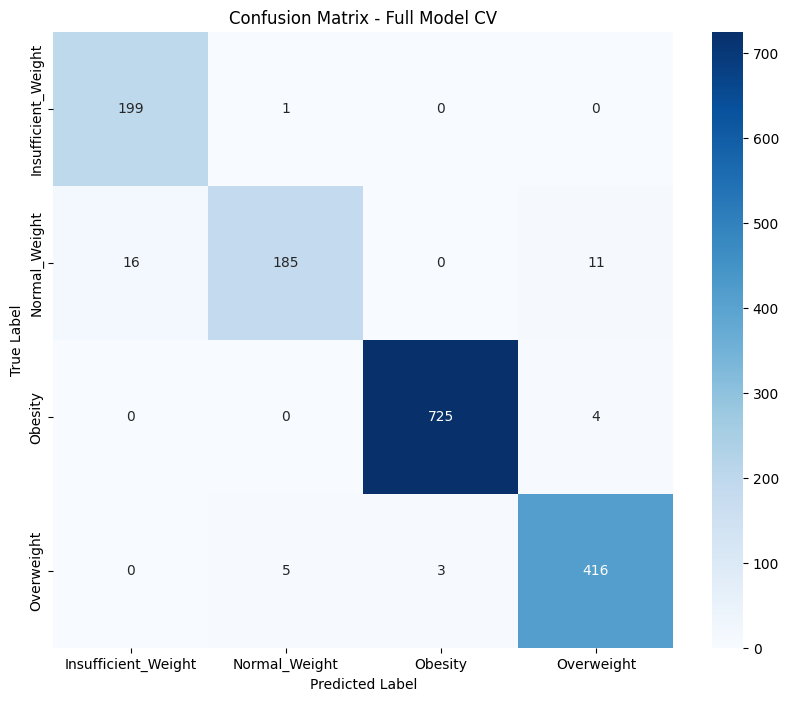

In [205]:
make_model(svm_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["svm"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.58      0.69      0.63       200
      Normal_Weight       0.45      0.31      0.36       212
            Obesity       0.68      0.96      0.79       729
         Overweight       0.64      0.22      0.33       424

           accuracy                           0.64      1565
          macro avg       0.58      0.54      0.53      1565
       weighted avg       0.62      0.64      0.59      1565



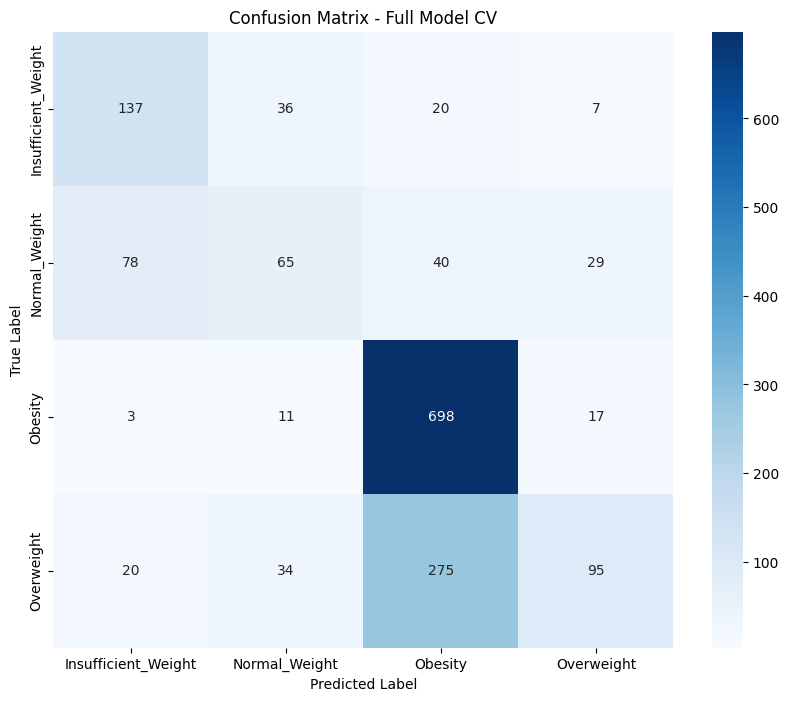

In [206]:
make_model(svm_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["svm"], result_no_anthro)

# Дерево решений

In [207]:
dt_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)


## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.98      0.95       200
      Normal_Weight       0.89      0.82      0.85       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.93      0.94      0.94       424

           accuracy                           0.95      1565
          macro avg       0.93      0.93      0.93      1565
       weighted avg       0.95      0.95      0.95      1565



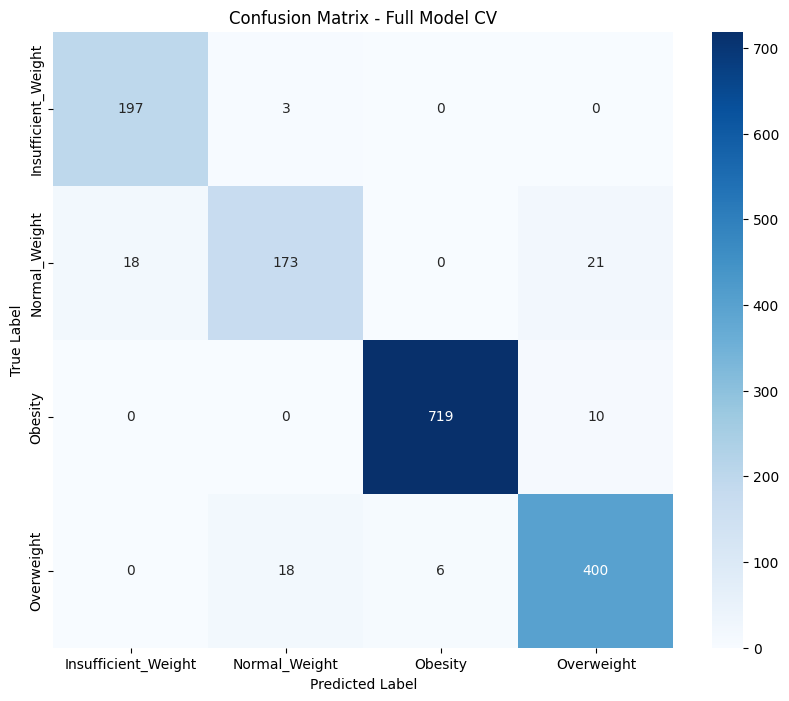

In [208]:
make_model(dt_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["tree"], result_hw)

## C BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.99      0.99       200
      Normal_Weight       0.97      0.94      0.95       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.98      0.98      0.98       424

           accuracy                           0.99      1565
          macro avg       0.98      0.98      0.98      1565
       weighted avg       0.99      0.99      0.99      1565



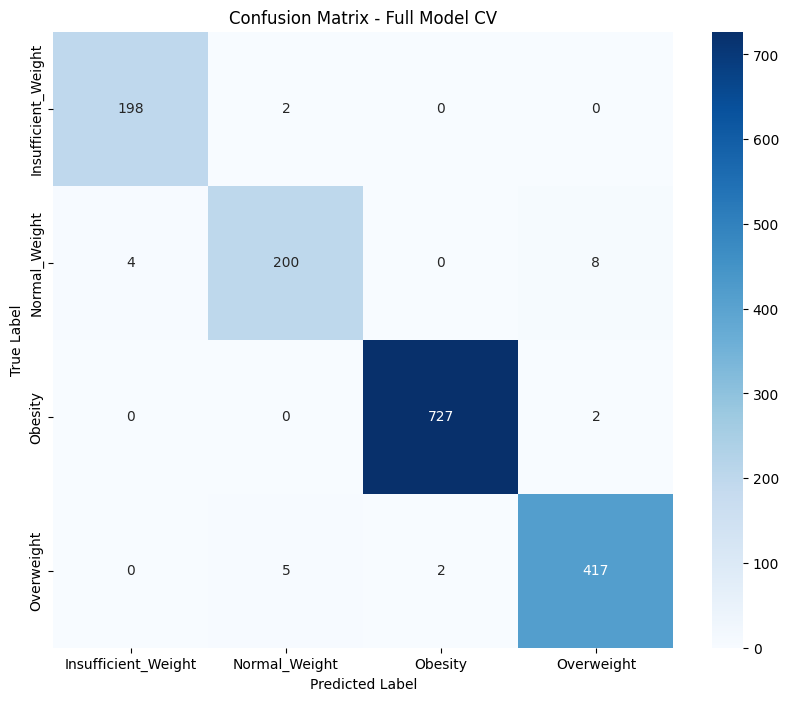

In [209]:
make_model(dt_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["tree"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.81      0.79       200
      Normal_Weight       0.53      0.52      0.53       212
            Obesity       0.86      0.85      0.86       729
         Overweight       0.69      0.69      0.69       424

           accuracy                           0.76      1565
          macro avg       0.71      0.72      0.72      1565
       weighted avg       0.76      0.76      0.76      1565



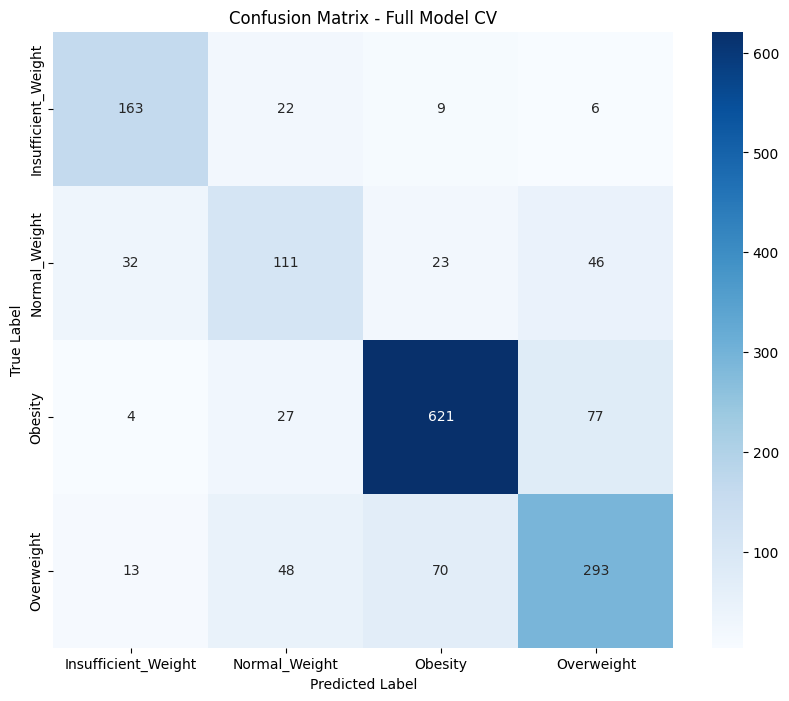

In [210]:
make_model(dt_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["tree"], result_no_anthro)

# Бэггинг (Random Forest)

In [211]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.94      0.94       200
      Normal_Weight       0.84      0.80      0.82       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.91      0.94      0.93       424

           accuracy                           0.95      1565
          macro avg       0.92      0.92      0.92      1565
       weighted avg       0.94      0.95      0.94      1565



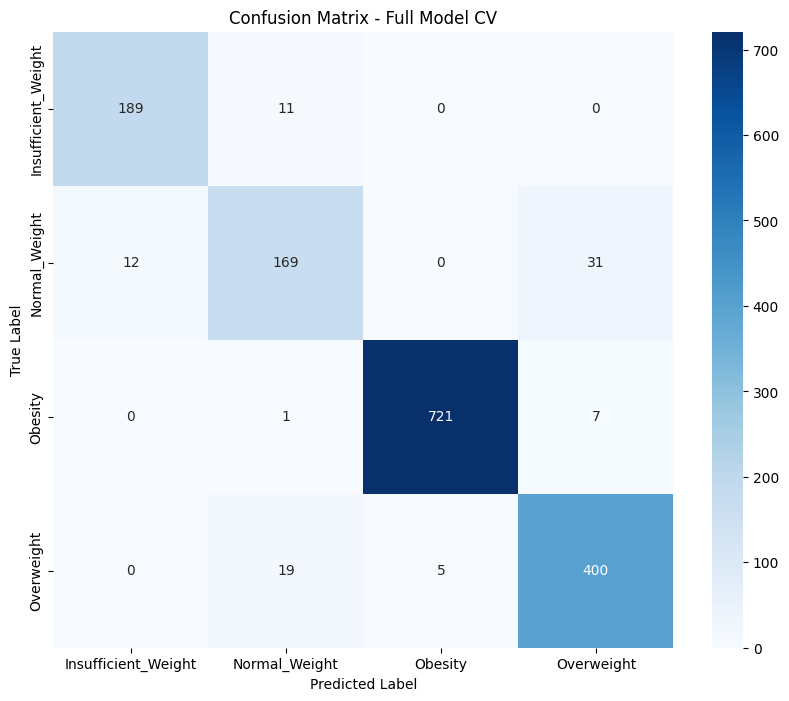

In [212]:
make_model(rf_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["rf"], result_hw)

## С BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98       200
      Normal_Weight       0.96      0.97      0.97       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.99      0.99      0.99       424

           accuracy                           0.99      1565
          macro avg       0.98      0.98      0.98      1565
       weighted avg       0.99      0.99      0.99      1565



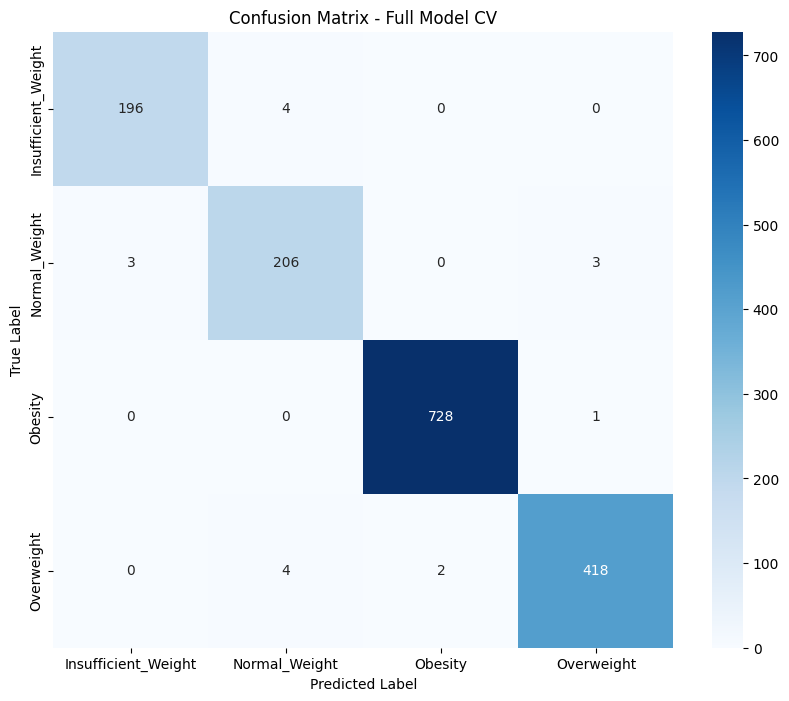

In [213]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.85      0.85       200
      Normal_Weight       0.65      0.54      0.59       212
            Obesity       0.80      0.95      0.87       729
         Overweight       0.77      0.60      0.67       424

           accuracy                           0.78      1565
          macro avg       0.77      0.73      0.74      1565
       weighted avg       0.78      0.78      0.78      1565



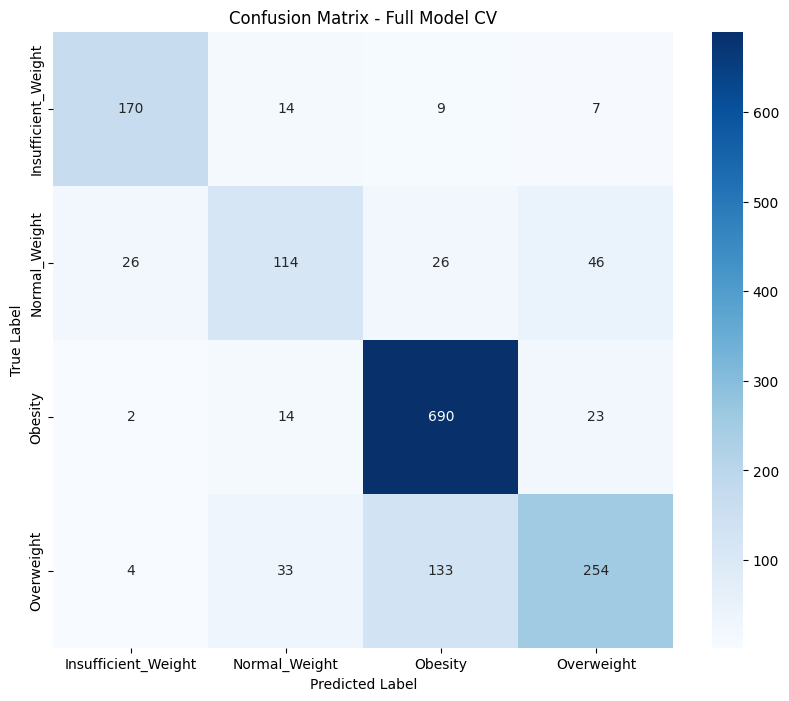

In [214]:
make_model(rf_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["rf"], result_no_anthro)

# Стекинг

In [215]:
estimators = [
    ('logreg', logreg_pipeline),
    ('svm', svm_pipeline),
    ('rf', rf_pipeline),
    ('dt', dt_pipeline)
]

final_estimator = LogisticRegression()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

stacking

StackingClassifier(cv=5,
                   estimators=[('logreg',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression(random_state=42))])),
                               ('svm',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(kernel='linear',
                                                     random_state=42))])),
                               ('rf',
                                Pipeline(steps=[('randomforestclassifier',
                                                 RandomForestClassifier(max_depth=10,
                                                                        n_jobs=-1,
                                                                        random_state=42))])),
                               ('dt',
                                Pipeline(steps=[('decisiontreeclassifier',
                                                 DecisionTreeClassifier(random_state=42))]))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

## Без BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.98      0.97       200
      Normal_Weight       0.96      0.91      0.93       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.97      0.98      0.98       424

           accuracy                           0.98      1565
          macro avg       0.97      0.97      0.97      1565
       weighted avg       0.98      0.98      0.98      1565



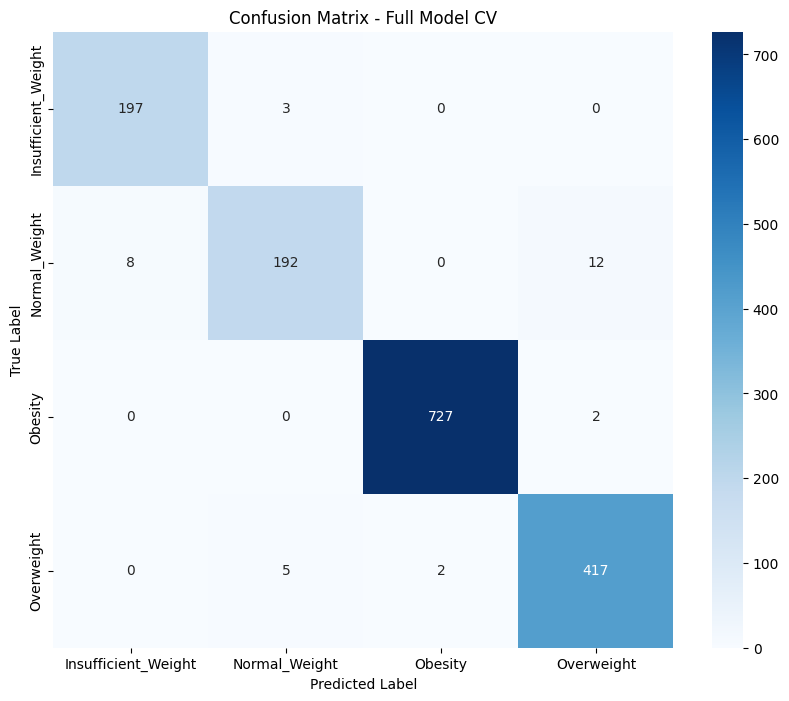

In [216]:
make_model(stacking, X_HW_train, Y_HW_train, MODEL_NAMES["stacking"], result_hw)

## C BMI

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.99      0.99      0.99       200
      Normal_Weight       0.98      0.98      0.98       212
            Obesity       1.00      1.00      1.00       729
         Overweight       0.99      0.99      0.99       424

           accuracy                           0.99      1565
          macro avg       0.99      0.99      0.99      1565
       weighted avg       0.99      0.99      0.99      1565



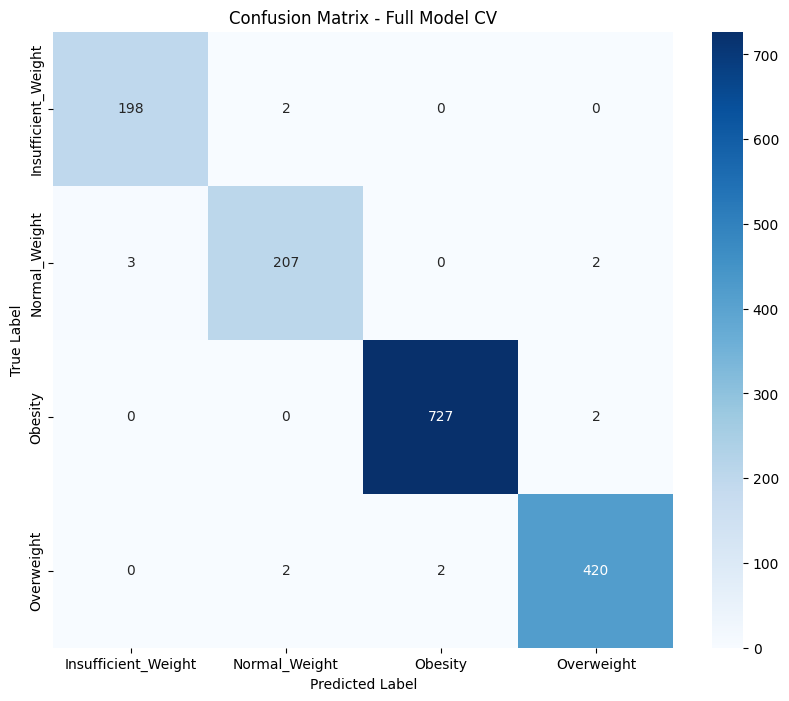

In [217]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi)

## Без BMI и без Роста и Веса

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      0.84      0.84       200
      Normal_Weight       0.66      0.56      0.61       212
            Obesity       0.87      0.91      0.89       729
         Overweight       0.74      0.74      0.74       424

           accuracy                           0.81      1565
          macro avg       0.78      0.76      0.77      1565
       weighted avg       0.80      0.81      0.81      1565



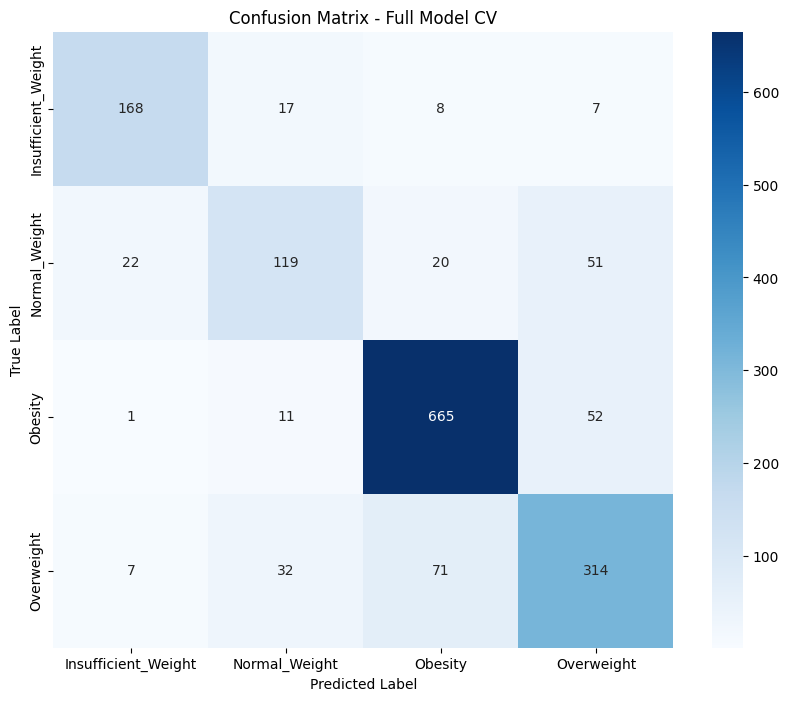

In [218]:
make_model(stacking, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["stacking"], result_no_anthro)

# Бустинг (CatBoost)

In [222]:
cbreg = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0
)

In [223]:
make_catboost_model(cbreg, X_HW_cat_train, Y_HW_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_hw)


Training on fold [0/5]

bestTest = 0.9777777778
bestIteration = 858

Training on fold [1/5]

bestTest = 0.9777070064
bestIteration = 970

Training on fold [2/5]

bestTest = 0.9681528662
bestIteration = 523

Training on fold [3/5]

bestTest = 0.9549839228
bestIteration = 597

Training on fold [4/5]

bestTest = 0.9710610932
bestIteration = 999



In [224]:
make_catboost_model(cbreg, X_BMI_cat_train, Y_BMI_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_bmi)

Training on fold [0/5]

bestTest = 0.980952381
bestIteration = 9

Training on fold [1/5]

bestTest = 0.9840764331
bestIteration = 84

Training on fold [2/5]

bestTest = 0.9936305732
bestIteration = 29

Training on fold [3/5]

bestTest = 0.9967845659
bestIteration = 13

Training on fold [4/5]

bestTest = 0.9871382637
bestIteration = 53



## Без BMI и без Роста и Веса

In [225]:
make_catboost_model(cbreg, X_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_no_anthro)

Training on fold [0/5]

bestTest = 0.7333333333
bestIteration = 501

Training on fold [1/5]

bestTest = 0.7675159236
bestIteration = 963

Training on fold [2/5]

bestTest = 0.7452229299
bestIteration = 955

Training on fold [3/5]

bestTest = 0.7395498392
bestIteration = 915

Training on fold [4/5]

bestTest = 0.7427652733
bestIteration = 950



# Таблица значений с каждой модели

In [226]:
def display_formatted_table(comparison_results: dict):
    if not comparison_results:
        print("Словарь результатов пуст.")
        return

    df_results = pd.DataFrame.from_dict(comparison_results, orient='index')

    try:
        df_sorted = df_results.sort_values(
            by=METRIC_COLUMNS["F1"],
            ascending=False
        )
    except KeyError:
        print(f"Ошибка: В результатах отсутствует колонка для сортировки по F1-метрике ('{METRIC_COLUMNS['F1']}'). Сортировка пропущена.")
        df_sorted = df_results

    pd.options.display.float_format = '{:.4f}'.format

    try:
        if METRIC_COLUMNS["TIME"] in df_sorted.columns:
            df_sorted[METRIC_COLUMNS["TIME"]] = pd.to_numeric(df_sorted[METRIC_COLUMNS["TIME"]], errors='coerce')
            df_sorted[METRIC_COLUMNS["TIME"]] = df_sorted[METRIC_COLUMNS["TIME"]].apply(lambda x: f'{x:.2f}')
    except Exception as e:
        print(f"Ошибка при форматировании колонки времени '{METRIC_COLUMNS['TIME']}': {e}")

    display(df_sorted)

In [227]:
print("Без BMI")
display_formatted_table(result_hw)
print("С BMI")
display_formatted_table(result_bmi)
print("Без BMI и без Роста и Веса")
display_formatted_table(result_no_anthro)

Без BMI


,F1-Score (Weighted Avg),Recall (Weighted Avg),Precision (Weighted Avg),Accuracy,Время CV (сек)
Стеггинг,0.9794,0.9796,0.9795,0.9796,13.05
Модель SVM,0.9708,0.9712,0.9722,0.9712,0.31
Деревья,0.9510,0.9514,0.9513,0.9514,0.16
Рандом Форест,0.9447,0.9450,0.9447,0.9450,3.12
Логистическая регрессия,0.9405,0.9425,0.9427,0.9425,3.16
catBoost,0.0000,0.0000,0.0000,0.9699,100.49


С BMI


,F1-Score (Weighted Avg),Recall (Weighted Avg),Precision (Weighted Avg),Accuracy,Время CV (сек)
Стеггинг,0.9917,0.9917,0.9917,0.9917,11.01
Рандом Форест,0.9891,0.9891,0.9892,0.9891,1.41
Деревья,0.9853,0.9853,0.9853,0.9853,0.08
Модель SVM,0.9741,0.9744,0.9749,0.9744,0.27
Логистическая регрессия,0.9553,0.9565,0.9573,0.9565,0.17
catBoost,0.0000,0.0000,0.0000,0.9885,100.83


Без BMI и без Роста и Веса


,F1-Score (Weighted Avg),Recall (Weighted Avg),Precision (Weighted Avg),Accuracy,Время CV (сек)
Стеггинг,0.8059,0.8089,0.8046,0.8089,12.15
Рандом Форест,0.7755,0.7847,0.7789,0.7847,1.56
Деревья,0.7588,0.7591,0.7588,0.7591,0.10
Модель SVM,0.5882,0.6358,0.6225,0.6358,0.54
Логистическая регрессия,0.5686,0.6013,0.5713,0.6013,0.14
catBoost,0.0000,0.0000,0.0000,0.7431,95.73


# Выводы

TODO: Сделать выводы